@author: chaoping

# Final project: Virginia state senate analysis
All data retrieved April 2025: <br>
[Population data](https://redistrictingdatahub.org/dataset/virginia-block-pl-94171-2020-by-table/): based on the decennial census at the Census Block level on 2020 Census Redistricting Data

[2020 County data](https://redistrictingdatahub.org/dataset/virginia-county-pl-94171-2020/): from 2020 Census Redistricting Data (P.L. 94-171) Shapefiles

[State Senate District data](https://redistrictingdatahub.org/dataset/2021-senate-of-virginia-districts-approved-plan/): 2021 State Senate Approved Plan

[2019 election data](https://redistrictingdatahub.org/dataset/vest-2019-virginia-state-senate-precinct-boundaries-and-election-results-shapefile/)**:**  VEST 2019 Virginia State Senate precinct boundaries and election results shapefile

[2017 election data](https://redistrictingdatahub.org/dataset/vest-2017-virginia-state-senate-special-precinct-boudaries-and-election-results-shapefile/)**:**  VEST 2017 Virginia State Senate special precinct boudaries and election results shapefile


In [1]:
import pandas as pd
import geopandas as gpd
import maup
from maup import smart_repair
import time
import os

In [2]:
import warnings
warnings.filterwarnings('ignore')

maup.progress.enabled = True

## Loading shape files and explore the data

In [3]:
# Load population file
population_df = gpd.read_file("./va_pl2020_b/va_pl2020_p2_b.shp")

#Load voting age population file
vap_df = gpd.read_file("./va_pl2020_b/va_pl2020_p4_b.shp")

#Load 2020 election data
vest19_df = gpd.read_file("./va_vest_19_statesenate/va_vest_19_statesenate.shp")

#Load county data
county_df = gpd.read_file("./va_pl2020_cnty/va_pl2020_cnty.shp")

#Load state senate district
sen_df = gpd.read_file("./va_sldu_adopted_2021/SCV FINAL SD.shp")

Check column names

In [4]:
print(population_df.columns)
print(vap_df.columns)
print(vest19_df.columns)
print(county_df.columns)
print(sen_df.columns)

Index(['GEOID20', 'SUMLEV', 'LOGRECNO', 'GEOID', 'COUNTY', 'P0020001',
       'P0020002', 'P0020003', 'P0020004', 'P0020005', 'P0020006', 'P0020007',
       'P0020008', 'P0020009', 'P0020010', 'P0020011', 'P0020012', 'P0020013',
       'P0020014', 'P0020015', 'P0020016', 'P0020017', 'P0020018', 'P0020019',
       'P0020020', 'P0020021', 'P0020022', 'P0020023', 'P0020024', 'P0020025',
       'P0020026', 'P0020027', 'P0020028', 'P0020029', 'P0020030', 'P0020031',
       'P0020032', 'P0020033', 'P0020034', 'P0020035', 'P0020036', 'P0020037',
       'P0020038', 'P0020039', 'P0020040', 'P0020041', 'P0020042', 'P0020043',
       'P0020044', 'P0020045', 'P0020046', 'P0020047', 'P0020048', 'P0020049',
       'P0020050', 'P0020051', 'P0020052', 'P0020053', 'P0020054', 'P0020055',
       'P0020056', 'P0020057', 'P0020058', 'P0020059', 'P0020060', 'P0020061',
       'P0020062', 'P0020063', 'P0020064', 'P0020065', 'P0020066', 'P0020067',
       'P0020068', 'P0020069', 'P0020070', 'P0020071', 'P002

## Clean the data

First, we put everything into utm crs.

In [5]:
population_df = population_df.to_crs(population_df.estimate_utm_crs())
vap_df = vap_df.to_crs(vap_df.estimate_utm_crs())
county_df = county_df.to_crs(county_df.estimate_utm_crs())
sen_df = sen_df.to_crs(sen_df.estimate_utm_crs())
vest19_df = vest19_df.to_crs(vest19_df.estimate_utm_crs())

Check with maup.doctor()

In [6]:
maup.doctor(population_df)

100%|█████████████████████████████████| 163491/163491 [01:08<00:00, 2388.54it/s]


True

In [7]:
maup.doctor(vap_df)

100%|█████████████████████████████████| 163491/163491 [01:08<00:00, 2378.21it/s]


True

In [8]:
maup.doctor(county_df)

100%|████████████████████████████████████████| 133/133 [00:00<00:00, 221.70it/s]


True

In [9]:
maup.doctor(sen_df)

100%|██████████████████████████████████████████| 40/40 [00:00<00:00, 109.12it/s]


True

In [10]:
maup.doctor(vest19_df)

100%|██████████████████████████████████████| 2585/2585 [00:03<00:00, 762.08it/s]


There are 82 overlaps.
There are 546 holes.
There are some invalid geometries.


False

We need to do smart repair with our 2020 election data.

We first nest within counties.

In [11]:
vest19_df = smart_repair(vest19_df, nest_within_regions = county_df)

100%|████████████████████████████████████████| 133/133 [00:00<00:00, 217.32it/s]


Snapping all geometries to a grid with precision 10^( -5 ) to avoid GEOS errors.


100%|████████████████████████████████████████| 133/133 [00:00<00:00, 550.80it/s]


Identifying overlaps...


100%|█████████████████████████████████████| 2948/2948 [00:02<00:00, 1212.22it/s]


Resolving overlaps and filling gaps...


100%|████████████████████████████████████████| 133/133 [00:00<00:00, 555.56it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify in region 2: 100%|███████████████| 2/2 [00:00<00:00,  2.54it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify in region 4: 100%|██████████████| 1/1 [00:00<00:00, 138.99it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify in region 7: 100%|███████████████| 2/2 [00:00<00:00, 78.74it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify in region 9: 100%|███████████████| 1/1 [00:00<00:00, 57.64it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify in region 10: 100%|███████

In [12]:
vest19_df = smart_repair(vest19_df, min_rook_length = 30)

Snapping all geometries to a grid with precision 10^( -5 ) to avoid GEOS errors.
Identifying overlaps...


100%|█████████████████████████████████████| 2636/2636 [00:00<00:00, 3632.67it/s]


Resolving overlaps...
Filling gaps...


Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]


Converting small rook adjacencies to queen...


100%|███████████████████████████████████████████| 4/4 [00:00<00:00, 3019.11it/s]


In [13]:
maup.doctor(vest19_df)

100%|██████████████████████████████████████| 2585/2585 [00:03<00:00, 798.35it/s]


True

## Put data in same geometry

Our data is clean.  We'll assign blocks to precincts and aggregate population data.

In [27]:
blocks_to_precincts_assignment = maup.assign(population_df.geometry, vest19_df.geometry)
vap_blocks_to_precincts_assignment = maup.assign(vap_df.geometry, vest19_df.geometry)

100%|██████████████████████████████████████| 2585/2585 [00:18<00:00, 141.36it/s]


These columns contains population data that we are interested.

In [28]:
pop_column_names = ['P0020001', 'P0020002', 'P0020005', 'P0020006', 'P0020007',
                    'P0020008', 'P0020009', 'P0020010', 'P0020011']

In [29]:
vap_column_names = ['P0040001', 'P0040002', 'P0040005', 'P0040006', 'P0040007',
                    'P0040008', 'P0040009', 'P0040010', 'P0040011']

We'll put all of the population columns into the election dataframe

In [31]:
for name in pop_column_names:
    vest19_df[name] = population_df[name].groupby(blocks_to_precincts_assignment).sum()
for name in vap_column_names:
    vest19_df[name] = vap_df[name].groupby(vap_blocks_to_precincts_assignment).sum()

check if we lose anyone

In [33]:
print(population_df['P0020001'].sum())
print(vest19_df['P0020001'].sum())
print(vap_df['P0040001'].sum())
print(vest19_df['P0040001'].sum())

8631393
8631393.0
6745054
6745054.0


rename the columns

In [34]:
rename_dict = {'P0020001': 'TOTPOP', 'P0020002': 'HISP', 'P0020005': 'NH_WHITE', 'P0020006': 'NH_BLACK', 'P0020007': 'NH_AMIN',
                    'P0020008': 'NH_ASIAN', 'P0020009': 'NH_NHPI', 'P0020010': 'NH_OTHER', 'P0020011': 'NH_2MORE',
                    'P0040001': 'VAP', 'P0040002': 'HVAP', 'P0040005': 'WVAP', 'P0040006': 'BVAP', 'P0040007': 'AMINVAP',
                                        'P0040008': 'ASIANVAP', 'P0040009': 'NHPIVAP', 'P0040010': 'OTHERVAP', 'P0040011': '2MOREVAP'}

In [36]:
vest19_df.rename(columns=rename_dict, inplace = True)

We'll drop the columns that we're not interested in (including non-Democratic and non-Republican votes).

In [38]:
vest19_df.drop(columns=[ 'G19SOVIND','G19SOVLIB','G19SOVWRI'], inplace=True)

In [40]:
vest19_df.columns

Index(['COUNTYFP', 'LOCALITY', 'VTDST', 'PRECINCT', 'SOV_DIST', 'G19SOVDEM',
       'G19SOVREP', 'geometry', 'TOTPOP', 'HISP', 'NH_WHITE', 'NH_BLACK',
       'NH_AMIN', 'NH_ASIAN', 'NH_NHPI', 'NH_OTHER', 'NH_2MORE', 'VAP', 'HVAP',
       'WVAP', 'BVAP', 'AMINVAP', 'ASIANVAP', 'NHPIVAP', 'OTHERVAP',
       '2MOREVAP'],
      dtype='object')

In [57]:
vest19_df.isna().sum()

COUNTYFP     0
LOCALITY     0
VTDST        0
PRECINCT     0
SOV_DIST     0
G19SOVDEM    0
G19SOVREP    0
geometry     0
TOTPOP       3
HISP         3
NH_WHITE     3
NH_BLACK     3
NH_AMIN      3
NH_ASIAN     3
NH_NHPI      3
NH_OTHER     3
NH_2MORE     3
VAP          3
HVAP         3
WVAP         3
BVAP         3
AMINVAP      3
ASIANVAP     3
NHPIVAP      3
OTHERVAP     3
2MOREVAP     3
dtype: int64

In [58]:
missing = vest19_df[vest19_df["TOTPOP"].isna()]
print(missing[["PRECINCT", "geometry"]])

         PRECINCT                                           geometry
2297  Yanceyville  POLYGON ((762011.887 4198178.217, 762225.168 4...
2300  Hadensville  MULTIPOLYGON (((764578.212 4195263.986, 764571...
2346   Kiln Creek  POLYGON ((899702.409 4120724.084, 899702.387 4...


In [59]:
vest19_df[vest19_df["PRECINCT"].isin(["Yanceyville", "Hadensville", "Kiln Creek"])]

,COUNTYFP,LOCALITY,VTDST,PRECINCT,SOV_DIST,G19SOVDEM,G19SOVREP,geometry,TOTPOP,HISP,...,NH_2MORE,VAP,HVAP,WVAP,BVAP,AMINVAP,ASIANVAP,NHPIVAP,OTHERVAP,2MOREVAP
2296,109,Louisa County,000402,Yanceyville,017,191,222,"POLYGON ((764755.307 4210986.590, 764759.132 4...",1266.0,26.0,...,48.0,982.0,19.0,736.0,184.0,1.0,5.0,0.0,2.0,35.0
2297,109,Louisa County,000402,Yanceyville,022,1,5,"POLYGON ((762011.887 4198178.217, 762225.168 4...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2300,075,Goochland County,000102,Hadensville,017,0,1,"MULTIPOLYGON (((764578.212 4195263.986, 764571...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2301,075,Goochland County,000102,Hadensville,022,395,740,"POLYGON ((758267.766 4199309.099, 758193.385 4...",2825.0,95.0,...,141.0,2237.0,57.0,1748.0,312.0,5.0,16.0,0.0,21.0,78.0
2345,700,Newport News City,000218,Kiln Creek,001,1347,0,"POLYGON ((899701.914 4120724.656, 899702.387 4...",6945.0,769.0,...,369.0,5681.0,578.0,3036.0,1331.0,14.0,431.0,18.0,30.0,243.0
2346,700,Newport News City,000218,Kiln Creek,002,46,0,"POLYGON ((899702.409 4120724.084, 899702.387 4...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [60]:
vest19_df.fillna(0, inplace=True)

## Visualize the cleaned map

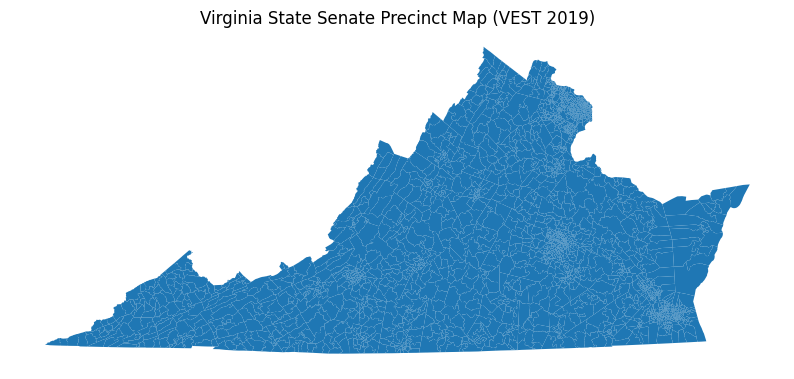

In [41]:
import matplotlib.pyplot as plt

vest19_df.plot(figsize=(10, 10))
plt.title("Virginia State Senate Precinct Map (VEST 2019)")
plt.axis("off")
plt.show()

save the shape file

In [61]:
directory = "./va_statesenate_19"
if not os.path.exists(directory):
    os.makedirs(directory)
vest19_df.to_file("./va_statesenate_19/va_statesenate_19.shp")

## Running Recom chain

The data is cleaned and we can run the recom chain now.

In [43]:
from gerrychain import Graph, Partition, proposals, updaters, constraints, accept, MarkovChain, Election
from gerrychain.updaters import cut_edges, Tally
from gerrychain.proposals import recom
from gerrychain.accept import always_accept
from functools import partial

In [62]:
shapefile_path = "./va_statesenate_19/va_statesenate_19.shp"
gdf = gpd.read_file(shapefile_path)
graph = Graph.from_geodataframe(gdf, adjacency="rook")

In [92]:
# Define updaters
updaters = {
    "population": Tally("TOTPOP", alias="population"),
    "cut_edges": cut_edges,
    "election": Election("election", {
        "Democratic": "G19SOVDEM",
        "Republican": "G19SOVREP"
    })
}

In [93]:
# Initial partition using Congressional Districting
initial_partition = Partition(
    graph, assignment="SOV_DIST", updaters=updaters 
)

In [111]:
# Define proposal
proposal = partial(
    recom, 
    pop_col="TOTPOP", 
    pop_target=sum(initial_partition["population"].values())/len(initial_partition), 
    epsilon=0.3, 
    node_repeats=2
)

In [95]:
# Define constraints
constraints_list = [
    constraints.within_percent_of_ideal_population(initial_partition, 0.4)
]

In [112]:
# Define Markov Chain
chain = MarkovChain(
    proposal=proposal,
    constraints=constraints_list,
    accept=always_accept,
    initial_state=initial_partition,
    total_steps=20000  
)

Collect statistics for efficiency gap, demo-won districts and cut edges.

In [113]:
from gerrychain.metrics import partisan

# Collect statistics
efficiency_gaps = []
dem_won_districts = []
cut_edges_list = []

for partition in chain:
    # Efficiency gap (using dem and rep votes per district)
    eg = partition["election"].efficiency_gap()
    efficiency_gaps.append(eg)

    # Democratic wins
    dem_wins = sum(1 for d, r in zip(partition["dem_votes"].values(), 
                                     partition["rep_votes"].values()) if d > r)
    dem_won_districts.append(dem_wins)

    # Number of cut edges
    cut_edges_list.append(len(partition["cut_edges"]))

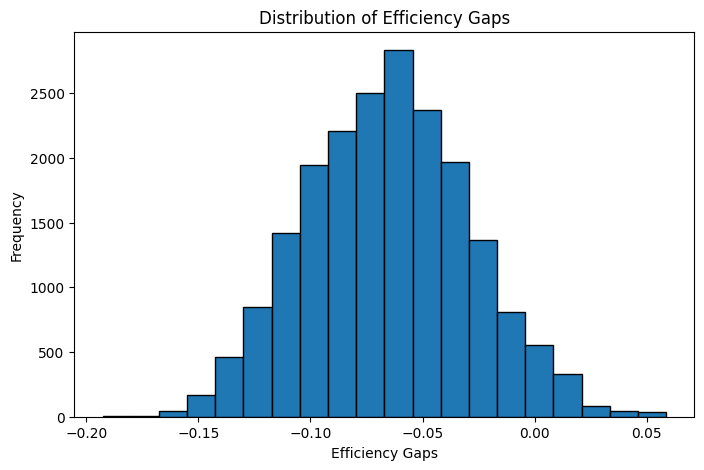

In [107]:
# Plot efficiency gaps
plt.figure(figsize=(8, 5))
plt.hist(efficiency_gaps, bins=20, edgecolor='black')
plt.title("Distribution of Efficiency Gaps")
plt.xlabel("Efficiency Gaps")
plt.ylabel("Frequency")
plt.show()

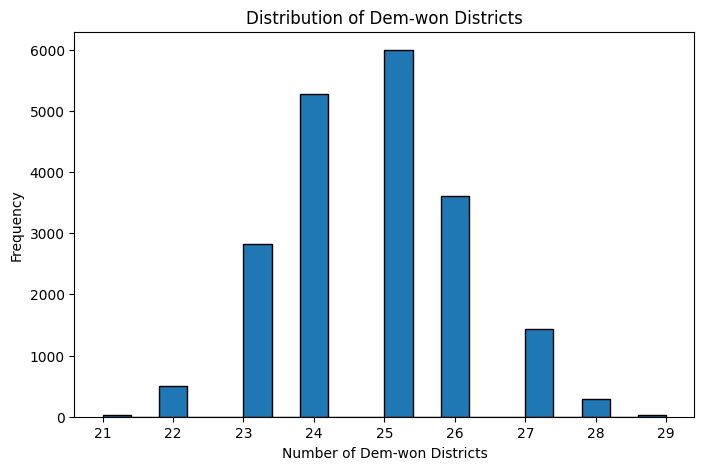

In [106]:
# Plot dem-won districts
plt.figure(figsize=(8, 5))
plt.hist(dem_won_districts, bins=20, edgecolor='black')
plt.title("Distribution of Dem-won Districts")
plt.xlabel("Number of Dem-won Districts")
plt.ylabel("Frequency")
plt.show()

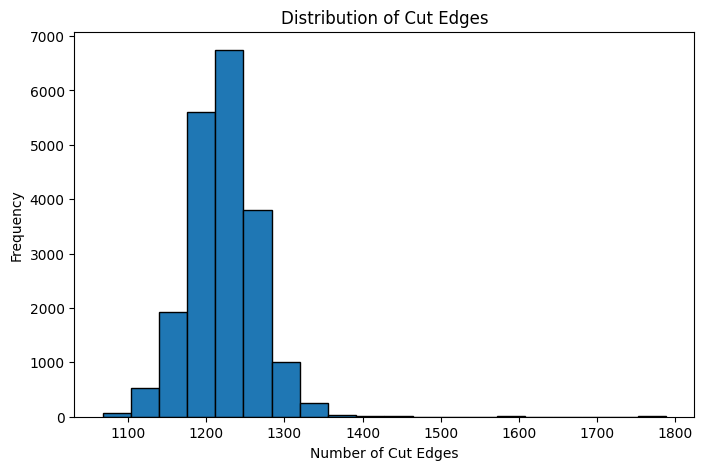

In [104]:
# Plot cut edges
plt.figure(figsize=(8, 5))
plt.hist(cut_edges_list, bins=20, edgecolor='black')
plt.title("Distribution of Cut Edges")
plt.xlabel("Number of Cut Edges")
plt.ylabel("Frequency")
plt.show()

## Run a longer chain for evidence of convergence

In [114]:
# Define Markov Chain
chain = MarkovChain(
    proposal=proposal,
    constraints=constraints_list,
    accept=always_accept,
    initial_state=initial_partition,
    total_steps=40000  
)

In [115]:
# Collect statistics
efficiency_gaps = []
dem_won_districts = []
cut_edges_list = []

for partition in chain:
    # Efficiency gap (using dem and rep votes per district)
    eg = partition["election"].efficiency_gap()
    efficiency_gaps.append(eg)

    # Democratic wins
    dem_wins = sum(1 for d, r in zip(partition["dem_votes"].values(), 
                                     partition["rep_votes"].values()) if d > r)
    dem_won_districts.append(dem_wins)

    # Number of cut edges
    cut_edges_list.append(len(partition["cut_edges"]))

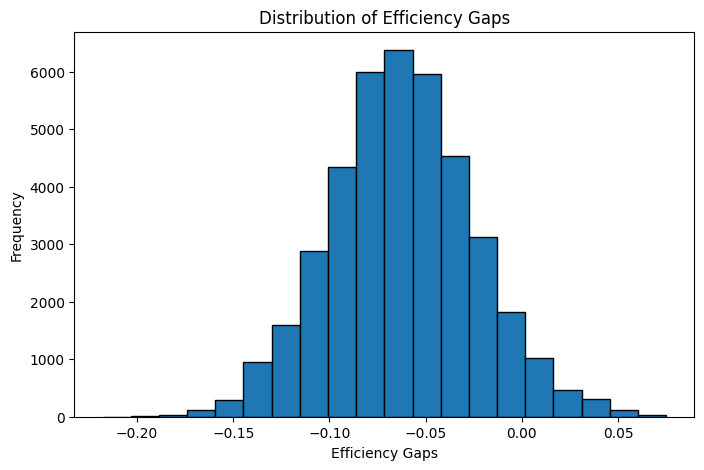

In [116]:
# Plot efficiency gaps
plt.figure(figsize=(8, 5))
plt.hist(efficiency_gaps, bins=20, edgecolor='black')
plt.title("Distribution of Efficiency Gaps")
plt.xlabel("Efficiency Gaps")
plt.ylabel("Frequency")
plt.show()

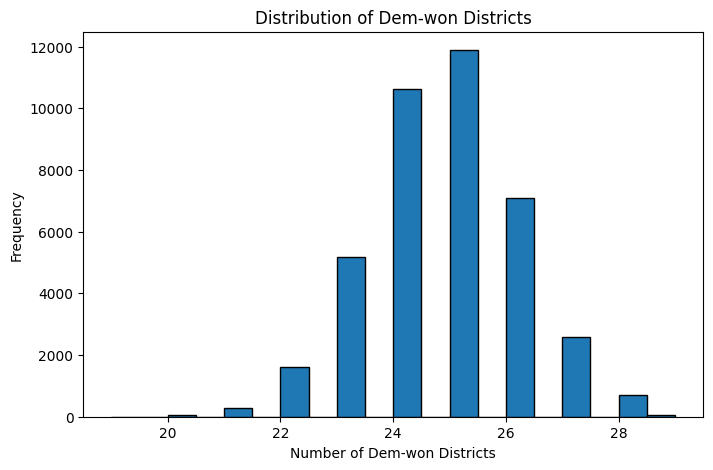

In [117]:
# Plot dem-won districts
plt.figure(figsize=(8, 5))
plt.hist(dem_won_districts, bins=20, edgecolor='black')
plt.title("Distribution of Dem-won Districts")
plt.xlabel("Number of Dem-won Districts")
plt.ylabel("Frequency")
plt.show()

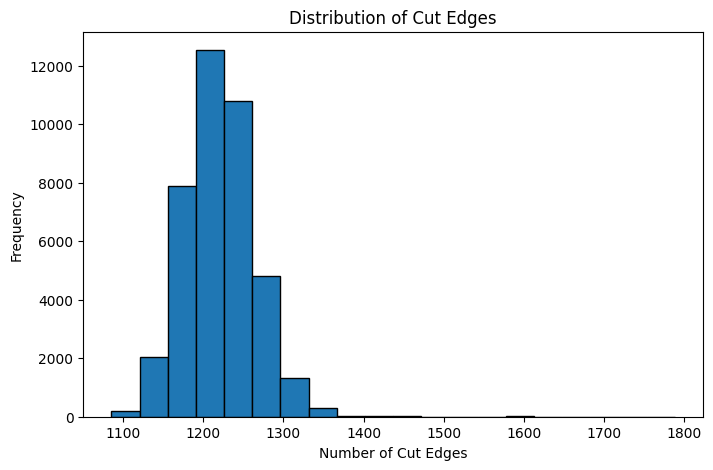

In [118]:
# Plot cut edges
plt.figure(figsize=(8, 5))
plt.hist(cut_edges_list, bins=20, edgecolor='black')
plt.title("Distribution of Cut Edges")
plt.xlabel("Number of Cut Edges")
plt.ylabel("Frequency")
plt.show()